# Gradient Descent

In [1]:
## linear regression using gradient descent

In [2]:
from sklearn.datasets import make_regression
import numpy as np

In [3]:
X,y = make_regression(n_samples=4, n_features=1, n_informative=1, n_targets=1,noise=80,random_state=13)

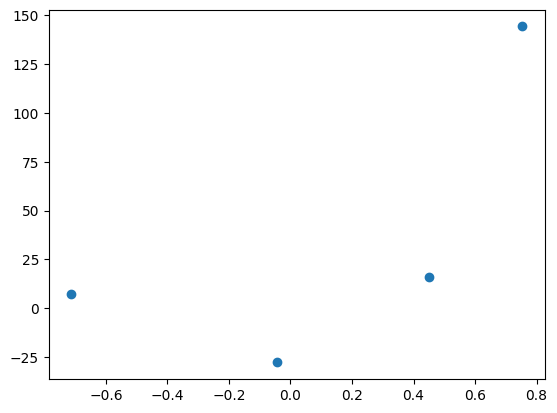

In [4]:
import matplotlib.pyplot as plt
plt.scatter(X,y)

In [5]:
# Lets apply OLS
from sklearn.linear_model import LinearRegression

In [7]:
# traing the model
reg = LinearRegression()
reg.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
y_pred=reg.predict(X)
y_pred

array([-29.65662909,  61.55941724,  22.67278832,  85.21770852])

In [22]:
X

array([[-0.71239066],
       [ 0.45181234],
       [-0.04450308],
       [ 0.75376638]])

In [23]:
# coefficient
reg.coef_

array([78.35063668])

In [24]:
# intercept
reg.intercept_

np.float64(26.15963284313262)

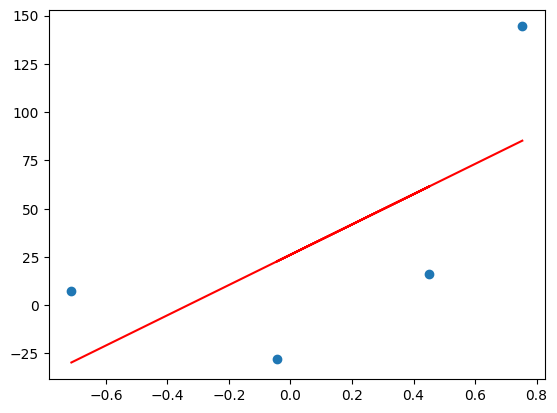

In [25]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red')   
plt.show()

In [28]:

# Lets apply Gradient Descent assuming slope is constant m = 78.35
# and let's assume the starting value for intercept b = 0
y_pred = ((78.35 * X) + 100).reshape(4)
y_pred

array([ 44.18419163, 135.39949674,  96.51318381, 159.05759577])

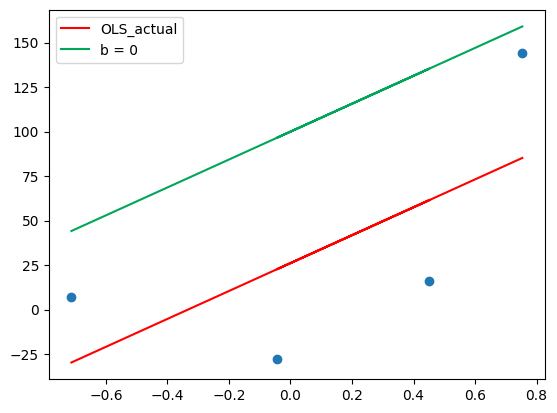

In [29]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS_actual')  
plt.plot(X,y_pred,color='#00a65a',label='b = 0')
plt.legend()
plt.show() 

In [30]:
m=78.35
b=0

loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

np.float64(-209.27763408209216)

In [31]:
# Lets take learning rate = 0.1
lr = 0.1

step_size = loss_slope*lr
step_size

np.float64(-20.927763408209216)

In [32]:
# Calculating the new intercept
b = b - step_size
b
   

np.float64(20.927763408209216)

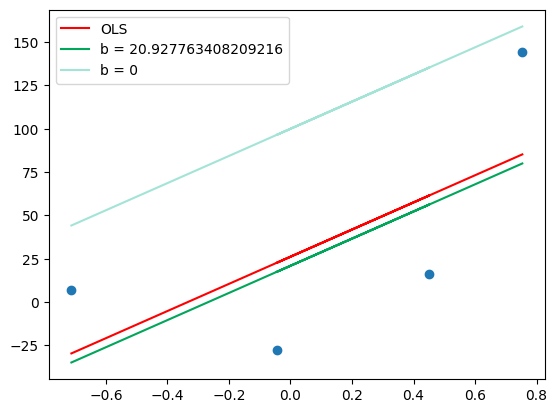

In [33]:
y_pred1 = ((78.35 * X) + b).reshape(4)

plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred1,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
plt.show()

In [34]:
# Iteration 2(at b=20.72)
loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

np.float64(-41.85552681641843)

In [35]:
step_size = loss_slope*lr
step_size

np.float64(-4.185552681641844)

In [36]:
b = b - step_size
b

np.float64(25.11331608985106)

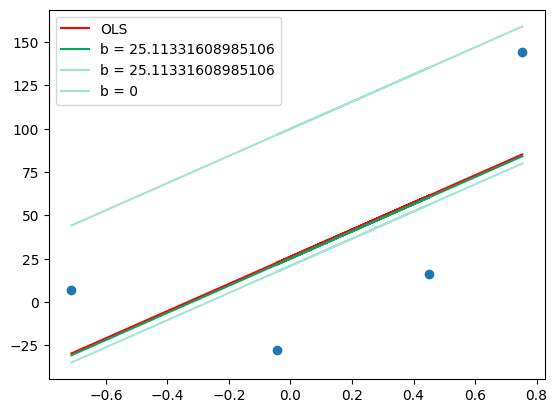

In [37]:
y_pred2 = ((78.35 * X) + b).reshape(4)

plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred2,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred1,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
plt.show()
     

In [38]:
# Iteration 3
loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

np.float64(-8.371105363283675)

In [39]:
step_size = loss_slope*lr
step_size

np.float64(-0.8371105363283675)

In [40]:
b = b - step_size
b
    

np.float64(25.95042662617943)

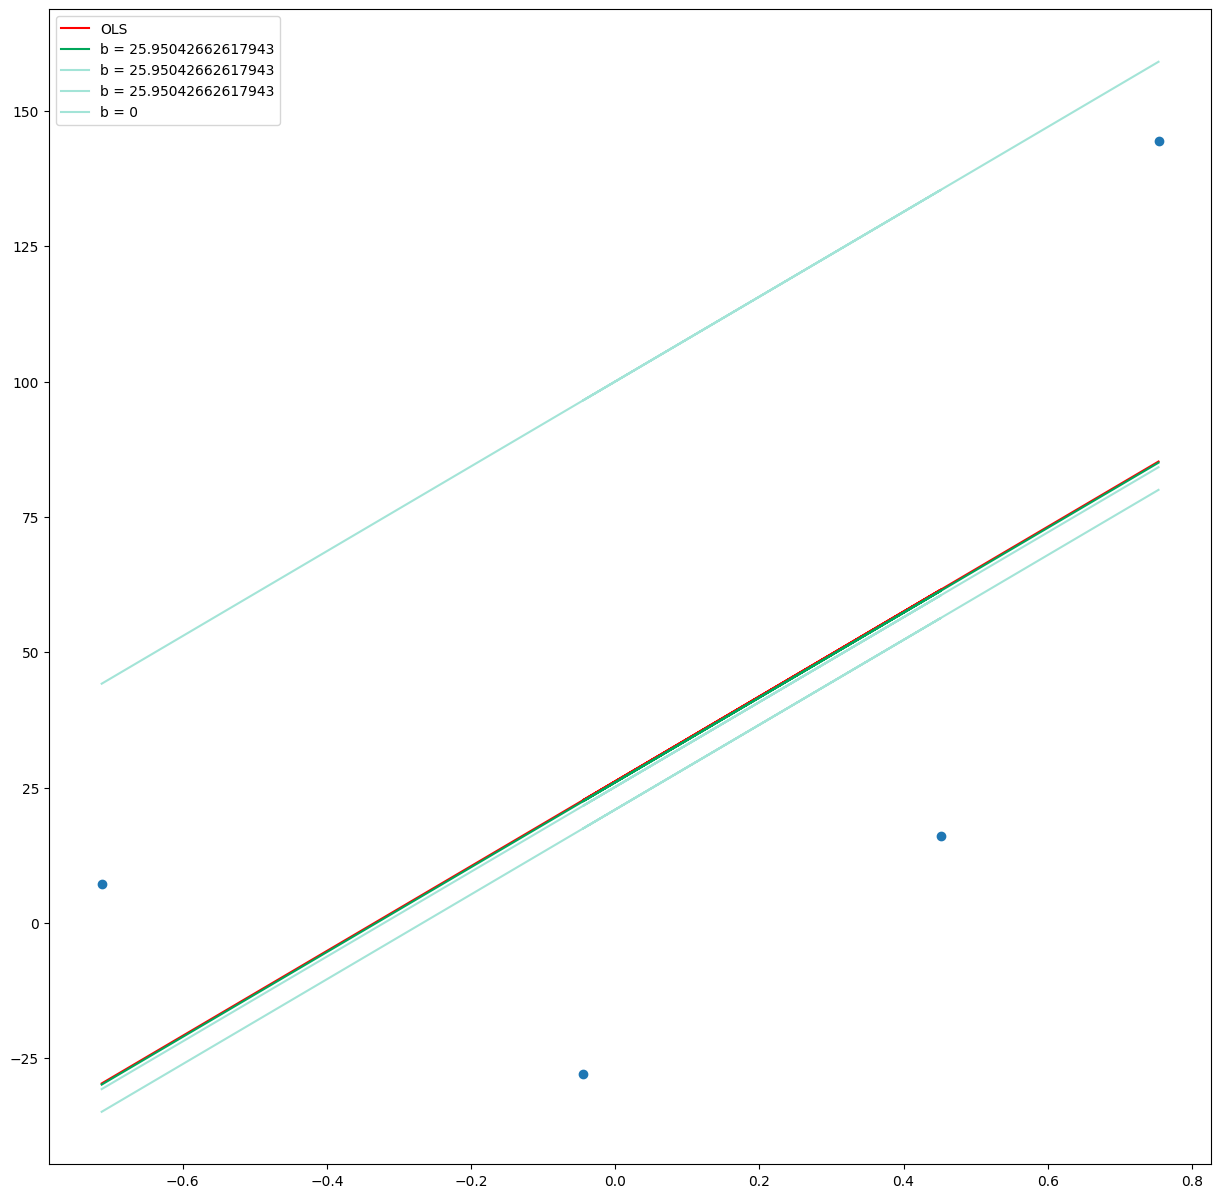

In [41]:
y_pred3 = ((78.35 * X) + b).reshape(4)

plt.figure(figsize=(15,15))
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred3,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred2,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred1,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
plt.show()

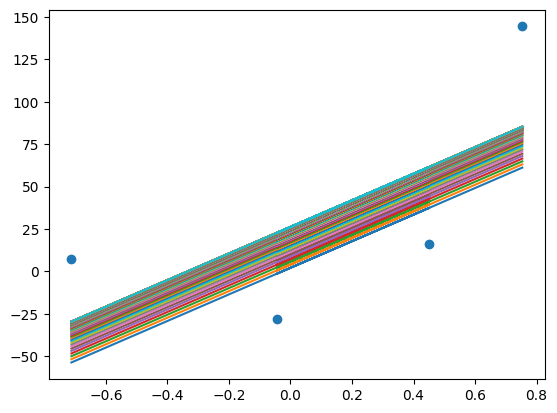

In [44]:
b = 0
m = 78.35
lr = 0.01

epochs = 100

for i in range(epochs):
  loss_slope = -2 * np.sum(y - m*X.ravel() - b)
  b = b - (lr * loss_slope)

  y_pred = m * X + b

  plt.plot(X,y_pred)

plt.scatter(X,y)

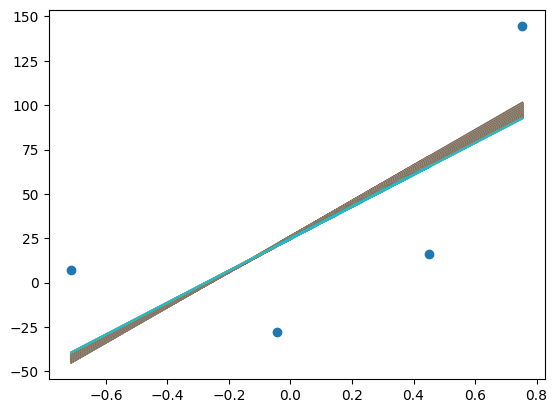

In [54]:
b==-120
m=100
lr=0.01
epochs=100

for i in range(epochs):
    slope_b = -2 * np.sum(y - m*X.ravel() - b)/X.shape[0]
    b=b-(lr*slope_b)

    slope_m= -2 * np.sum((y - m*X.ravel() - b)*X.ravel())/X.shape[0]
    m=m-(lr*slope_m)

    y_pred=m*X + b

    plt.plot(X,y_pred)

plt.scatter(X,y)

In [45]:
X.ravel() 

array([-0.71239066,  0.45181234, -0.04450308,  0.75376638])

In [47]:
X.shape

(4, 1)

In [53]:
y*[1,2,3,4]

array([  7.21786552,  32.09219849, -83.51268499, 577.46752756])